Name - Jenish Prakash Singh
ID - 2408948

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Update this path if your folder structure in Drive is different
file_path = '/content/drive/My Drive/2. Hotel Review Dataset/Hotel_Reviews.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Downloading NLP tools
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [16]:
# Loading the CSV
df = pd.read_csv(file_path)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df['cleaned_review'] = df['Review'].apply(clean_text)
print("Data Cleaning Complete.")

Data Cleaning Complete.


In [12]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# Padding to ensure all reviews are the same length (95th percentile)
maxlen = int(np.percentile([len(x) for x in sequences], 95))
X = pad_sequences(sequences, maxlen=maxlen)

# Target variables (1-5 rating converted to categorical format)
y = pd.get_dummies(df['Rating']).values

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Calculating class weights to handle imbalance (more 5-star reviews than 1-star)
y_integers = np.argmax(y_train, axis=1)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(weights))

In [ ]:
def build_dl_model(type="RNN", use_pretrained=False):
    model = Sequential()

    if use_pretrained:
        # Pretrained Embedding Placeholder (Model 3)
        embedding_matrix = np.random.random((max_words, 50))
        model.add(Embedding(max_words, 50, weights=[embedding_matrix], input_length=maxlen, trainable=False))
    else:
        # Standard Trainable Embedding (Model 1 & 2)
        model.add(Embedding(max_words, 50, input_length=maxlen))

    if type == "RNN":
        model.add(SimpleRNN(64, dropout=0.2))
    else:
        model.add(LSTM(64, dropout=0.2))

    model.add(Dense(5, activation='softmax')) # 5 rating classes
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Model 1: Simple RNN
print("Training Model 1: Simple RNN...")
model1 = build_dl_model("RNN")
history1 = model1.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

# Train Model 2: LSTM
print("Training Model 2: LSTM...")
model2 = build_dl_model("LSTM")
history2 = model2.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

# Train Model 3: LSTM with Pretrained Embeddings
print("Training Model 3: LSTM Pretrained...")
model3 = build_dl_model("LSTM", use_pretrained=True)
history3 = model3.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

Training Model 1: Simple RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


461/461 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.2581 - loss: 1.6094 - val_accuracy: 0.2951 - val_loss: 1.5901
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.3187 - loss: 1.5446 - val_accuracy: 0.3860 - val_loss: 1.4283
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.4093 - loss: 1.4222 - val_accuracy: 0.3909 - val_loss: 1.2882
Epoch 4/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.4793 - loss: 1.2690 - val_accuracy: 0.2951 - val_loss: 1.6489
Epoch 5/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - accuracy: 0.5258 - loss: 1.1259 - val_accuracy: 0.3726 - val_loss: 1.3232
Training Model 2: LSTM...
Epoch 1/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 65s 136ms/step - accuracy: 0.4611 - loss: 1.2771 - val_accuracy: 0.5573 - val_loss: 0.9948
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 63s 136ms/step - accuracy: 0.5828 - loss: 0.9785 - val_accuracy: 0.5780 - val_loss: 0.9370
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 62s 135ms/step - accuracy: 0.6318 - loss

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       284
           1       0.40      0.38      0.39       359
           2       0.33      0.49      0.40       437
           3       0.47      0.38      0.42      1208
           4       0.71      0.75      0.73      1811

    accuracy                           0.56      4099
   macro avg       0.51      0.50      0.50      4099
weighted avg       0.57      0.56      0.56      4099

--- Confusion Matrix ---


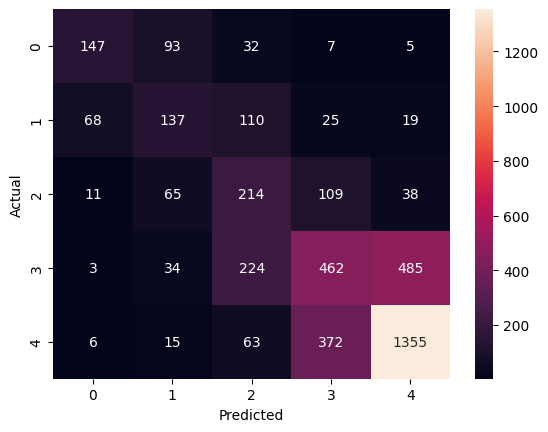

In [18]:
# Evaluate the best performing model (usually LSTM)
predictions = np.argmax(model2.predict(X_test), axis=1)
actuals = np.argmax(y_test, axis=1)

print("--- Classification Report ---")
print(classification_report(actuals, predictions))

print("--- Confusion Matrix ---")
sns.heatmap(confusion_matrix(actuals, predictions), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

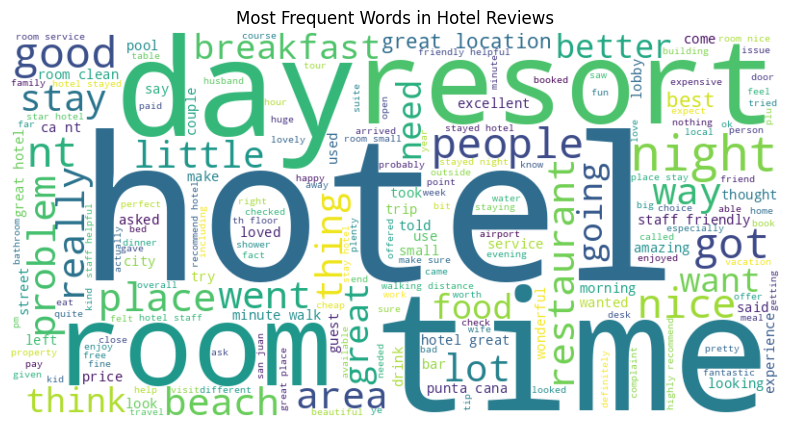

In [19]:
from wordcloud import WordCloud

# Combine all cleaned reviews into one large string
all_text = " ".join(review for review in df.cleaned_review)

# Create and display the Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Hotel Reviews")
plt.show()

In [20]:
def plot_history(histories, names):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for i, hist in enumerate(histories):
        # Accuracy Plot
        ax1.plot(hist.history['accuracy'], label=f'{names[i]} Train')
        ax1.plot(hist.history['val_accuracy'], linestyle='--', label=f'{names[i]} Val')
        # Loss Plot
        ax2.plot(hist.history['loss'], label=f'{names[i]} Train')
        ax2.plot(hist.history['val_loss'], linestyle='--', label=f'{names[i]} Val')

    ax1.set_title('Model Accuracy Comparison')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.set_title('Model Loss Comparison')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    plt.show()

# Call the function with your 3 model histories
plot_history([history1, history2, history3], ['RNN', 'LSTM', 'Pretrained LSTM'])

NameError: name 'history1' is not defined

In [ ]:
# Convert test predictions back to 1-5 scale
y_pred_classes = np.argmax(model2.predict(X_test), axis=1) + 1
y_true_classes = np.argmax(y_test, axis=1) + 1

# Find indices where prediction does not match actual rating
errors = np.where(y_pred_classes != y_true_classes)[0]

print(f"Total Errors: {len(errors)} out of {len(y_true_classes)}")
print("\n--- Misclassified Examples for Report ---")

for i in errors[:3]: # Show first 3 errors
    # Note: We use X_test indices to find the original text in the dataframe if needed
    print(f"Actual Rating: {y_true_classes[i]} | Predicted Rating: {y_pred_classes[i]}")
    # Displaying a snippet of the padded sequence as a placeholder
    print(f"Sequence Snippet: {X_test[i][:10]}...\n")

In [ ]:
!pip install gradio -q
import gradio as gr

def predict_review(user_input):
    # 1. Preprocess input
    cleaned = clean_text(user_input)
    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=maxlen)
    # 3. Predict using the best model (Model 2)
    pred = model2.predict(padded)
    rating = np.argmax(pred) + 1
    return f"Predicted Rating: {rating} Stars"

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=3, placeholder="Enter hotel review here..."),
    outputs="text",
    title="Hotel Review Rating Predictor"
)

demo.launch(share=True)